In [1]:

import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/confusion_matrix_cv.png
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/Meander_HandPD.csv
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/paper_style_metrics_baseline_rgb.csv
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/cv_fold_metrics.csv
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/Spiral_HandPD.csv
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/paper_style_metrics_vgg16_baseline_rgb.csv
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/cv_fold_metrics_vgg16_baseline_rgb.csv
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/confusion_matrix_cv_vgg16_baseline_rgb.png
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/outputs/features/0100-4__overlap_categorical.npy
/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset/outputs/features/0068-4__curvature.npy

In [2]:

# Import e Setup
import os
import re
from pathlib import Path
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
 
# Seed fisso per la riproducibilità
# Copre tutte le fonti di casualità del training: inizializzazione dei pesi,
# ordine di mescolamento dei dati nel DataLoader, augmentation (flip/rotazione).
# Senza seed, ogni esecuzione dello stesso codice produce un modello leggermente
# diverso e i risultati non sono confrontabili tra run successive.
SEED = 42
 
 
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)          # no-op se non c'è GPU, innocuo
    torch.backends.cudnn.deterministic = True  # forza algoritmi cuDNN deterministici
    torch.backends.cudnn.benchmark = False     # disattiva l'euristica di cuDNN che sceglie
                                                 # l'algoritmo più veloce provandone diversi
                                                 # (introdurrebbe non-determinismo)
 
 
def seed_worker(worker_id):
    """Da passare come worker_init_fn ai DataLoader con num_workers > 0.
    Senza questo, i processi worker del DataLoader ereditano lo stesso
    stato casuale dal processo principale al momento del fork, e possono
    finire per applicare la STESSA augmentation (stesso flip, stesso
    angolo di rotazione) a immagini diverse elaborate da worker diversi
    — un dettaglio sottile ma importante per una riproducibilità reale."""
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)
 
 
set_seed(SEED)
print(f"Seed fissato a {SEED} per riproducibilità.")
 
INPUT_BASE_DIR = Path('/kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset')
 
 
def _find_dataset_root(search_root: Path) -> Path:
    """Cerca ricorsivamente, sotto search_root, la cartella che contiene
    davvero 'Meander_HandPD.csv' — gestisce automaticamente eventuali
    livelli di nidificazione extra introdotti dall'estrazione dello zip
    caricato su Kaggle."""
    if (search_root / 'Meander_HandPD.csv').exists():
        return search_root
    matches = list(search_root.rglob('Meander_HandPD.csv'))
    if matches:
        found_root = matches[0].parent
        print(f"NOTA: 'Meander_HandPD.csv' non era nella cartella attesa "
              f"({search_root}), ma è stato trovato automaticamente in "
              f"{found_root} — uso questo percorso.")
        return found_root
    raise FileNotFoundError(
        f"Non trovo 'Meander_HandPD.csv' da nessuna parte sotto {search_root}. "
        f"Verifica il nome esatto del dataset caricato (pannello 'Data' a destra "
        f"nel notebook Kaggle, o 'Copy path' sul file che ti serve)."
    )
 
 
# Cartella di lettura (read-only): immagini, CSV ufficiali, maschere.
IMAGES_BASE_DIR = _find_dataset_root(INPUT_BASE_DIR)
MASKS_DIR_CHECK  = IMAGES_BASE_DIR / 'outputs' / 'masks'
 
# Cartella di scrittura (l'unica scrivibile su Kaggle): risultati, pesi, grafici.
OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
 
BASE_DIR = str(IMAGES_BASE_DIR)   # usato in lettura (CSV/immagini)
 
# Se True, salva i pesi del modello migliore di ogni fold
SAVE_FOLD_WEIGHTS = False
FOLD_WEIGHTS_TEMPLATE = os.path.join(str(OUTPUT_DIR), 'densenet121_baseline_rgb_fold{fold}_best.pth')
 
print(f"IMAGES_BASE_DIR (lettura): {IMAGES_BASE_DIR}")
print(f"OUTPUT_DIR (scrittura):    {OUTPUT_DIR}")
if not MASKS_DIR_CHECK.exists():
    print(f"ATTENZIONE: {MASKS_DIR_CHECK} non esiste — verifica la struttura del dataset caricato.")
else:
    n_masks = len(list(MASKS_DIR_CHECK.glob('*.npy')))
    print(f"  -> {n_masks} file .npy trovati in outputs/masks (attesi: 730)")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Seed fissato a 42 per riproducibilità.
IMAGES_BASE_DIR (lettura): /kaggle/input/datasets/vanessadellaquila/handpdtesi/HandPD_Dataset
OUTPUT_DIR (scrittura):    /kaggle/working
  -> 1472 file .npy trovati in outputs/masks (attesi: 730)
PyTorch version: 2.10.0+cu128
CUDA available: True


In [3]:

# Caricamento metadati (lo split viene fatto dalla cross-validation)
DEFAULT_SEARCH_DIRS = [
    "MeanderHandPD", "Meander_HandPD",
    "SpiralHandPD", "Spiral_HandPD",
]
 
 
def infer_label_and_type(image_path):
    """Deduce LABEL (0=Control, 1=Patient) e DRAW_TYPE (Spiral/Meander)
    dai nomi delle cartelle nel percorso, indipendentemente dalla
    variante di naming usata (con/senza underscore)."""
    parts_lower = [p.lower() for p in image_path.split(os.sep)]
 
    label = None
    for p in parts_lower:
        if 'control' in p:
            label = 0
        elif 'patient' in p:
            label = 1
 
    draw_type = None
    for p in parts_lower:
        if 'spiral' in p:
            draw_type = 'Spiral'
        elif 'meander' in p:
            draw_type = 'Meander'
 
    return label, draw_type
 
 
def find_dataset_images(root_dir):
    images = []
    for sub in DEFAULT_SEARCH_DIRS:
        d = os.path.join(root_dir, sub)
        if os.path.exists(d):
            for dirpath, _, filenames in os.walk(d):
                for file_name in filenames:
                    if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        images.append(os.path.join(dirpath, file_name))
    return sorted(images)
 
 
def build_true_patient_lookup(base_dir):
    """Costruisce, a partire dai CSV ufficiali del dataset, una lookup
    {(DRAW_TYPE, IMAGE_NAME_FISICO): vero_id_persona}.

    Il nome file riportato in IMAGE_NAME nel CSV NON corrisponde sempre al
    nome fisico su disco. Per i tracciati Meander, il CSV rinumera
    localmente i 4 tentativi di ogni sessione come -1..-4, mentre su disco
    gli stessi 4 tentativi sono salvati come -5..-8 (numerazione globale
    della sessione, che includeva anche i 4 tentativi Spiral come -1..-4).

    L'appaiamento avviene per POSIZIONE all'interno della stessa sessione
    (_ID_EXAM): i file fisici sono ordinati per suffisso numerico crescente
    e le righe CSV nel loro ordine originale. Non assume un offset fisso,
    quindi resta valido anche per le Spiral (dove il nome fisico coincide
    già col CSV). Le sessioni in cui il numero di righe CSV non coincide con
    quello dei file fisici trovati vengono escluse (e stampate a schermo)
    invece di essere appaiate alla cieca."""
    base_dir = Path(base_dir)  # accetta sia str sia Path
    lookup = {}
 
    csv_map = {
        'Meander': base_dir / 'Meander_HandPD.csv',
        'Spiral':  base_dir / 'Spiral_HandPD.csv',
    }
 
    # Directory fisiche in cui cercare i file per ciascun tipo, per
    # ricostruire il pairing posizionale reale (non solo dal CSV).
    physical_dirs = {
        'Meander': [base_dir / "MeanderHandPD", base_dir / "Meander_HandPD"],
        'Spiral':  [base_dir / "SpiralHandPD",  base_dir / "Spiral_HandPD"],
    }
 
    for draw_type, csv_path in csv_map.items():
        if not csv_path.exists():
            print(f"ATTENZIONE: CSV non trovato per {draw_type}: {csv_path}.")
            continue
 
        csv_df = pd.read_csv(csv_path)
 
        # Raccogli tutti i file fisici di questo tipo, ovunque si trovino
        physical_files = []
        for d in physical_dirs[draw_type]:
            if d.exists():
                physical_files.extend(d.rglob("*.jpg"))
                physical_files.extend(d.rglob("*.png"))
 
        # Raggruppa i file fisici per prefisso sessione (_ID_EXAM, 4 cifre)
        physical_by_exam = {}
        for p in physical_files:
            m = re.match(r'(\d+)-(\d+)\.\w+', p.name)
            if not m:
                continue
            exam_prefix, suffix = m.group(1), int(m.group(2))
            physical_by_exam.setdefault(exam_prefix, []).append((suffix, p.name))
 
        n_matched, n_mismatch = 0, 0
        for exam_id, group in csv_df.groupby('_ID_EXAM'):
            exam_prefix = f"{int(exam_id):04d}"
            physical_group = sorted(physical_by_exam.get(exam_prefix, []))
            csv_rows = group.to_dict('records')  # ordine originale nel CSV
 
            if len(physical_group) != len(csv_rows):
                n_mismatch += 1
                continue  # non appaiare alla cieca se i conteggi non tornano
 
            for (_, physical_name), row in zip(physical_group, csv_rows):
                lookup[(draw_type, physical_name)] = f"{int(row['CLASS_TYPE'])}_{int(row['ID_PATIENT'])}"
                n_matched += 1
 
        print(f"[{draw_type}] sessioni appaiate: {n_matched} immagini, "
              f"{n_mismatch} sessioni con conteggio non corrispondente (escluse)")
 
    return lookup
 
def load_and_prepare_metadata_from_folders(base_dir):
    data = []
    skipped_no_label = 0
    skipped_no_patient_match = 0
 
    patient_lookup = build_true_patient_lookup(base_dir)
 
    for image_path in find_dataset_images(base_dir):
        label, draw_type = infer_label_and_type(image_path)
        if label is None or draw_type is None:
            skipped_no_label += 1
            continue
 
        # Vero identificativo di persona, letto dal CSV ufficiale
        # (CLASS_TYPE + ID_PATIENT), NON dal prefisso del nome file
        # (che è _ID_EXAM, identificativo di seduta, non di persona).
        file_name = os.path.basename(image_path)
        true_patient_id = patient_lookup.get((draw_type, file_name))
        if true_patient_id is None:
            skipped_no_patient_match += 1
            continue
 
        data.append({
            'IMAGE_PATH': image_path,
            'LABEL':      label,
            'DRAW_TYPE':  draw_type,
            'ID_PATIENT': true_patient_id
        })
 
    df = pd.DataFrame(data)
 
    if skipped_no_label:
        print(f"Attenzione: {skipped_no_label} immagini scartate "
              f"(cartella non riconosciuta come Control/Patient).")
    if skipped_no_patient_match:
        print(f"Attenzione: {skipped_no_patient_match} immagini scartate "
              f"(nessuna corrispondenza nel CSV ufficiale, ID paziente non verificabile).")
 
    return df
 
 
# Creazione del DataFrame leggendo le cartelle
df = load_and_prepare_metadata_from_folders(BASE_DIR)
 
if df.empty:
    raise ValueError(
        "Nessuna immagine trovata. Controlla che esistano le cartelle "
        "Spiral_HandPD/SpiralPatients, Spiral_HandPD/SpiralControl, "
        "Meander_HandPD/MeanderPatients, Meander_HandPD/MeanderControl "
        f"dentro {BASE_DIR}"
    )
 
print(f"Totale immagini trovate: {len(df)}")
print(f"Distribuzione classi:\n{df['LABEL'].value_counts().rename({0:'Control', 1:'Patient'})}")
print(f"Pazienti unici: {df['ID_PATIENT'].nunique()}")

[Meander] sessioni appaiate: 368 immagini, 0 sessioni con conteggio non corrispondente (escluse)
[Spiral] sessioni appaiate: 368 immagini, 0 sessioni con conteggio non corrispondente (escluse)
Totale immagini trovate: 736
Distribuzione classi:
LABEL
Patient    592
Control    144
Name: count, dtype: int64
Pazienti unici: 54


In [4]:

# Dataset PyTorch e trasformazioni
class HandPDDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
 
    def __len__(self):
        return len(self.dataframe)
 
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['IMAGE_PATH']
        label    = self.dataframe.iloc[idx]['LABEL']
 
        image = Image.open(img_path).convert('RGB')
 
        if self.transform:
            image = self.transform(image)
 
        return image, torch.tensor(label, dtype=torch.float32)
 
 
img_size = 224  # risoluzione richiesta dai modelli pre-addestrati su ImageNet
                 # (la CNN custom usa invece 128)
 
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
 
# Augmentation solo sul training set
transform_train = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])
 
# Nessuna augmentation su val e test
transform_eval = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])
 
batch_size = 16  # ridotto rispetto ai 32 della CNN custom: DenseNet121 a 224x224
                  # occupa molta più memoria GPU

In [5]:

# DenseNet121 con Transfer Learning da ImageNet
# A differenza di BaselineCNN (costruita da zero), qui si riusa
# DenseNet121 pre-addestrata su ImageNet: variante leggera (8M parametri),
# scelta per limitare il rischio di overfitting sul dataset di poche
# centinaia di immagini. La connettività densa (ogni layer riceve in input
# le feature di tutti i layer precedenti) aiuta il riuso delle feature con
# pochi dati di training. Il backbone convoluzionale resta congelato
# (salvo il primo conv se adattato a canali != 3): si allena solo la nuova
# testa di classificazione.
def build_densenet121_model():
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    model.classifier = nn.Linear(model.classifier.in_features, 1)
    return model
 
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [6]:

# Funzioni di training/valutazione per un singolo fold
def train_one_fold(train_df, val_df, epochs, device):
    """Allena un nuovo modello su train_df, seleziona i pesi migliori
    in base alla val_loss su val_df e restituisce il modello con i
    pesi migliori caricati."""
 
    train_dataset = HandPDDataset(train_df, transform=transform_train)
    val_dataset   = HandPDDataset(val_df,   transform=transform_eval)
 
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                               num_workers=2, pin_memory=True, worker_init_fn=seed_worker)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                               num_workers=2, pin_memory=True, worker_init_fn=seed_worker)
 
    model = build_densenet121_model().to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
 
    best_val_loss = float('inf')
    best_state    = copy.deepcopy(model.state_dict())
 
    for epoch in range(1, epochs + 1):
 
        # TRAINING
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
 
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
 
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(1)  # squeeze(1) evita il collasso a scalare con batch size = 1
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
 
            train_loss    += loss.item()
            preds          = (torch.sigmoid(outputs) >= 0.5).float()
            train_correct += (preds == labels).sum().item()
            train_total   += labels.size(0)
 
        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc  = train_correct / train_total
 
        # VALIDATION
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
 
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
 
                outputs = model(inputs).squeeze(1)
                loss       = criterion(outputs, labels)
                val_loss  += loss.item()
 
                preds        = (torch.sigmoid(outputs) >= 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total   += labels.size(0)
 
        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc  = val_correct / val_total
 
        scheduler.step(avg_val_loss)
 
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state    = copy.deepcopy(model.state_dict())
            marker = " ← best"
        else:
            marker = ""
 
        print(
            f"    Epoch {epoch:>2}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}{marker}"
        )
 
    model.load_state_dict(best_state)
    return model
 
 
def evaluate_model(model, eval_df, device):
    """Valuta il modello su eval_df e restituisce predizioni, label vere e
    probabilita' (queste ultime necessarie per calcolare AUC e AUPR, che
    richiedono uno score continuo e non una predizione già binarizzata)."""
    eval_dataset = HandPDDataset(eval_df, transform=transform_eval)
    eval_loader  = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False,
                               num_workers=2, pin_memory=True, worker_init_fn=seed_worker)
 
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
 
    with torch.no_grad():
        for inputs, labels in eval_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze(1)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
 
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
 
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)
 
 
def print_both_classes_metrics(y_true, y_pred, header):
    """Stampa accuracy + precision/recall/f1 per ENTRAMBE le classi
    (0 = Control, 1 = Patient)."""
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
 
    print("\n" + "-"*50)
    print(f"   {header}")
    print("-"*50)
    print(f"  Accuracy complessiva: {acc:.4f}")
    print(f"  {'Classe':<10}{'Precision':>12}{'Recall':>12}{'F1-Score':>12}{'Support':>10}")
    for cls, name in zip([0, 1], ['Control', 'Patient']):
        print(f"  {name:<10}{prec[cls]:>12.4f}{rec[cls]:>12.4f}{f1[cls]:>12.4f}{support[cls]:>10d}")
    print("-"*50)
 
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'support': support}
 
 
def compute_paper_style_metrics(y_true, y_pred, y_prob):
    """Calcola le 5 metriche: Accuracy, Sensitivity, Specificity, AUC, AUPR.

    NB terminologico: Sensitivity è il Recall calcolato sulla classe
    'positiva' (qui Patient, LABEL=1) — misura quanti Patient reali vengono
    correttamente identificati. Specificity è il Recall calcolato sulla
    classe 'negativa' (qui Control, LABEL=0) — misura quanti Control reali
    vengono correttamente identificati. Coincidono quindi esattamente con
    Recall_Patient e Recall_Control già calcolati altrove in questo script.
    AUC e AUPR richiedono le probabilità (score continuo), non le
    predizioni già binarizzate a soglia 0.5."""
    acc = accuracy_score(y_true, y_pred)
    _, rec, _, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    sensitivity = rec[1]  # Recall sulla classe Patient (positiva)
    specificity = rec[0]  # Recall sulla classe Control (negativa)
    auc = roc_auc_score(y_true, y_prob)
    aupr = average_precision_score(y_true, y_prob)
    return {
        'Accuracy': acc, 'Sensitivity': sensitivity, 'Specificity': specificity,
        'AUC': auc, 'AUPR': aupr,
    }
 
 
def print_paper_style_metrics(metrics_dict, header):
    print("\n" + "="*55)
    print(f"   {header}")
    print("   (metriche nello stile del paper di riferimento)")
    print("="*55)
    for name in ['Accuracy', 'Sensitivity', 'Specificity', 'AUC', 'AUPR']:
        print(f"  {name:<14}: {metrics_dict[name]:.4f}")
    print("="*55)


In [7]:

 
# Cross-Validation patient-aware (GroupKFold)
N_SPLITS = 5      # numero di fold della cross-validation
EPOCHS   = 15     # meno delle 20 usate per BaselineCNN: con il backbone
                   # DenseNet121 congelato la convergenza è tipicamente più rapida
VAL_FRACTION_WITHIN_FOLD = 0.15  # frazione (patient-aware) di train usata come validation interna
 
gkf = GroupKFold(n_splits=N_SPLITS)
 
fold_metrics       = []   # metriche per ciascun fold (entrambe le classi)
paper_fold_metrics = []   # le 5 metriche (Accuracy, Sensitivity, Specificity, AUC, AUPR), per ciascun fold
oof_preds      = []   # predizioni out-of-fold, accumulate su tutti i fold
oof_labels     = []   # etichette vere corrispondenti
oof_probs      = []   # probabilita' out-of-fold (necessarie per AUC/AUPR aggregate)
 
print(f"\nAvvio {N_SPLITS}-Fold Cross-Validation patient-aware "
      f"(gruppi = ID_PATIENT, {len(df)} immagini, {df['ID_PATIENT'].nunique()} pazienti)")
 
for fold, (trainval_idx, test_idx) in enumerate(gkf.split(df, groups=df['ID_PATIENT']), start=1):
 
    trainval_df = df.iloc[trainval_idx].reset_index(drop=True)
    test_df     = df.iloc[test_idx].reset_index(drop=True)
 
    # Split interno train/val (patient-aware) SOLO per early stopping/scheduler,
    # non per la valutazione finale del fold.
    gss_val = GroupShuffleSplit(n_splits=1, test_size=VAL_FRACTION_WITHIN_FOLD, random_state=42)
    train_idx, val_idx = next(gss_val.split(trainval_df, groups=trainval_df['ID_PATIENT']))
 
    train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
    val_df   = trainval_df.iloc[val_idx].reset_index(drop=True)
 
    # Verifica anti-leakage tra i tre insiemi del fold corrente
    train_patients = set(train_df['ID_PATIENT'])
    val_patients   = set(val_df['ID_PATIENT'])
    test_patients  = set(test_df['ID_PATIENT'])
    assert len(train_patients & val_patients) == 0
    assert len(train_patients & test_patients) == 0
    assert len(val_patients   & test_patients) == 0
 
    print(f"\n{'='*60}")
    print(f"FOLD {fold}/{N_SPLITS} | "
          f"Train: {len(train_df)} img ({len(train_patients)} pz) | "
          f"Val: {len(val_df)} img ({len(val_patients)} pz) | "
          f"Test: {len(test_df)} img ({len(test_patients)} pz)")
    print(f"{'='*60}")
 
    # Training del fold
    model = train_one_fold(train_df, val_df, epochs=EPOCHS, device=device)
 
    if SAVE_FOLD_WEIGHTS:
        torch.save(model.state_dict(), FOLD_WEIGHTS_TEMPLATE.format(fold=fold))
 
    # Valutazione sul fold di test (mai visto durante training/val di questo fold)
    preds, labels, probs = evaluate_model(model, test_df, device)
 
    metrics = print_both_classes_metrics(labels, preds, header=f"RISULTATI FOLD {fold}")
    metrics['fold'] = fold
    fold_metrics.append(metrics)
 
    paper_metrics = compute_paper_style_metrics(labels, preds, probs)
    print_paper_style_metrics(paper_metrics, header=f"FOLD {fold} - Metriche stile paper")
    paper_metrics['fold'] = fold
    paper_fold_metrics.append(paper_metrics)
 
    oof_preds.append(preds)
    oof_labels.append(labels)
    oof_probs.append(probs)
 


Avvio 5-Fold Cross-Validation patient-aware (gruppi = ID_PATIENT, 736 immagini, 54 pazienti)

FOLD 1/5 | Train: 466 img (36 pz) | Val: 118 img (7 pz) | Test: 152 img (11 pz)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 166MB/s]


    Epoch  1/15 | Train Loss: 0.5550 | Train Acc: 0.7489 | Val Loss: 0.4241 | Val Acc: 0.9322 ← best
    Epoch  2/15 | Train Loss: 0.5129 | Train Acc: 0.7768 | Val Loss: 0.3615 | Val Acc: 0.9322 ← best
    Epoch  3/15 | Train Loss: 0.4804 | Train Acc: 0.7768 | Val Loss: 0.3204 | Val Acc: 0.9322 ← best
    Epoch  4/15 | Train Loss: 0.5063 | Train Acc: 0.7790 | Val Loss: 0.2761 | Val Acc: 0.9322 ← best
    Epoch  5/15 | Train Loss: 0.4439 | Train Acc: 0.7811 | Val Loss: 0.2741 | Val Acc: 0.9322 ← best
    Epoch  6/15 | Train Loss: 0.4266 | Train Acc: 0.7918 | Val Loss: 0.2512 | Val Acc: 0.9322 ← best
    Epoch  7/15 | Train Loss: 0.4317 | Train Acc: 0.8026 | Val Loss: 0.2867 | Val Acc: 0.9322
    Epoch  8/15 | Train Loss: 0.4575 | Train Acc: 0.8176 | Val Loss: 0.3712 | Val Acc: 0.9322
    Epoch  9/15 | Train Loss: 0.4140 | Train Acc: 0.7918 | Val Loss: 0.2860 | Val Acc: 0.9322
    Epoch 10/15 | Train Loss: 0.3947 | Train Acc: 0.8112 | Val Loss: 0.2793 | Val Acc: 0.9322
    Epoch 11/15 | 


   RISULTATI CROSS-VALIDATION (5-Fold) — media ± std per fold
  Accuracy: 0.8143 ± 0.0255
  Classe           Precision          Recall        F1-Score
  Control       0.5333 ±0.4522    0.0750 ±0.0919    0.1198 ±0.1328
  Patient       0.8157 ±0.0303    0.9950 ±0.0100    0.8960 ±0.0147

--------------------------------------------------
   RISULTATI AGGREGATI SU TUTTE LE PREDIZIONI OUT-OF-FOLD
--------------------------------------------------
  Accuracy complessiva: 0.8139
  Classe       Precision      Recall    F1-Score   Support
  Control         0.7692      0.0694      0.1274       144
  Patient         0.8147      0.9949      0.8958       592
--------------------------------------------------

Classification report completo (out-of-fold):
              precision    recall  f1-score   support

     Control       0.77      0.07      0.13       144
     Patient       0.81      0.99      0.90       592

    accuracy                           0.81       736
   macro avg       0.79      

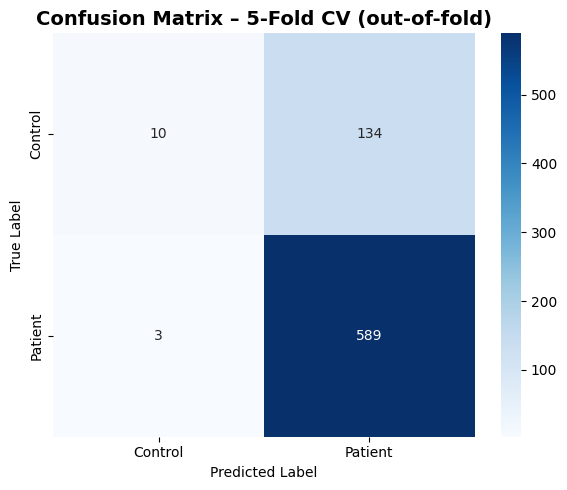

Confusion matrix salvata in: /kaggle/working/confusion_matrix_cv_densenet121_baseline_rgb.png

Riepilogo metriche per fold:
 Fold  Accuracy  Precision_Control  Recall_Control  F1_Control  Precision_Patient  Recall_Patient  F1_Patient
    1  0.802632           1.000000          0.0625    0.117647           0.800000           1.000    0.888889
    2  0.786667           0.000000          0.0000    0.000000           0.786667           1.000    0.880597
    3  0.794521           1.000000          0.0625    0.117647           0.791667           1.000    0.883721
    4  0.833333           0.000000          0.0000    0.000000           0.833333           1.000    0.909091
    5  0.854167           0.666667          0.2500    0.363636           0.866667           0.975    0.917647

Riepilogo salvato in: /kaggle/working/cv_fold_metrics_densenet121_baseline_rgb.csv


In [8]:

# Risultati aggregati della Cross-Validation
oof_preds  = np.concatenate(oof_preds)
oof_labels = np.concatenate(oof_labels)
oof_probs  = np.concatenate(oof_probs)
 
# Media e deviazione standard delle metriche calcolate per fold
mean_acc = np.mean([m['accuracy'] for m in fold_metrics])
std_acc  = np.std([m['accuracy'] for m in fold_metrics])
 
mean_prec = np.mean([m['precision'] for m in fold_metrics], axis=0)
std_prec  = np.std([m['precision'] for m in fold_metrics], axis=0)
 
mean_rec = np.mean([m['recall'] for m in fold_metrics], axis=0)
std_rec  = np.std([m['recall'] for m in fold_metrics], axis=0)
 
mean_f1 = np.mean([m['f1'] for m in fold_metrics], axis=0)
std_f1  = np.std([m['f1'] for m in fold_metrics], axis=0)
 
print("\n" + "="*60)
print(f"   RISULTATI CROSS-VALIDATION ({N_SPLITS}-Fold) — media ± std per fold")
print("="*60)
print(f"  Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
print(f"  {'Classe':<10}{'Precision':>16}{'Recall':>16}{'F1-Score':>16}")
for cls, name in zip([0, 1], ['Control', 'Patient']):
    print(f"  {name:<10}"
          f"{mean_prec[cls]:>10.4f} ±{std_prec[cls]:<5.4f}"
          f"{mean_rec[cls]:>10.4f} ±{std_rec[cls]:<5.4f}"
          f"{mean_f1[cls]:>10.4f} ±{std_f1[cls]:<5.4f}")
print("="*60)
 
# Metriche aggregate su TUTTE le predizioni out-of-fold
# (ogni immagine del dataset viene valutata esattamente una volta,
#  dal fold in cui era nel test set)
print_both_classes_metrics(
    oof_labels, oof_preds,
    header="RISULTATI AGGREGATI SU TUTTE LE PREDIZIONI OUT-OF-FOLD"
)
 
print("\nClassification report completo (out-of-fold):")
print(classification_report(
    oof_labels, oof_preds, target_names=['Control', 'Patient'], zero_division=0
))
 
# Confusion Matrix aggregata (out-of-fold)
cm = confusion_matrix(oof_labels, oof_preds)
 
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Control', 'Patient'],
    yticklabels=['Control', 'Patient']
)
plt.title(f'Confusion Matrix – {N_SPLITS}-Fold CV (out-of-fold)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(os.path.join(str(OUTPUT_DIR), 'confusion_matrix_cv_densenet121_baseline_rgb.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Confusion matrix salvata in: {os.path.join(str(OUTPUT_DIR), 'confusion_matrix_cv_densenet121_baseline_rgb.png')}")
 
# Riepilogo tabellare per fold
summary_df = pd.DataFrame([
    {
        'Fold': m['fold'],
        'Accuracy': m['accuracy'],
        'Precision_Control': m['precision'][0], 'Recall_Control': m['recall'][0], 'F1_Control': m['f1'][0],
        'Precision_Patient': m['precision'][1], 'Recall_Patient': m['recall'][1], 'F1_Patient': m['f1'][1],
    }
    for m in fold_metrics
])
print("\nRiepilogo metriche per fold:")
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(str(OUTPUT_DIR), 'cv_fold_metrics_densenet121_baseline_rgb.csv'), index=False)
print(f"\nRiepilogo salvato in: {os.path.join(str(OUTPUT_DIR), 'cv_fold_metrics_densenet121_baseline_rgb.csv')}")

In [9]:

# Metriche: Accuracy, Sensitivity, Specificity, AUC, AUPR
# Sensitivity = Recall_Patient e Specificity = Recall_Control (già calcolati
# sopra) riproposti con questa nomenclatura, insieme ad AUC e AUPR (che
# richiedono le probabilità, raccolte tramite evaluate_model).
paper_summary_df = pd.DataFrame(paper_fold_metrics)[['fold', 'Accuracy', 'Sensitivity', 'Specificity', 'AUC', 'AUPR']]
paper_summary_df.columns = ['Fold', 'Accuracy', 'Sensitivity', 'Specificity', 'AUC', 'AUPR']
 
paper_mean = paper_summary_df[['Accuracy', 'Sensitivity', 'Specificity', 'AUC', 'AUPR']].mean()
paper_std  = paper_summary_df[['Accuracy', 'Sensitivity', 'Specificity', 'AUC', 'AUPR']].std(ddof=0)
 
oof_paper_metrics = compute_paper_style_metrics(oof_labels, oof_preds, oof_probs)
 
print("\n" + "#"*60)
print("#  ESPERIMENTO 1 - BASELINE RGB: Accuracy, Sensitivity, Specificity, AUC, AUPR")
print("#"*60)
print("\nPer fold:")
print(paper_summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nMedia ± deviazione standard sui 5 fold:")
for name in ['Accuracy', 'Sensitivity', 'Specificity', 'AUC', 'AUPR']:
    print(f"  {name:<14}: {paper_mean[name]:.4f} ± {paper_std[name]:.4f}")
print("\nAggregato out-of-fold (OOF):")
for name in ['Accuracy', 'Sensitivity', 'Specificity', 'AUC', 'AUPR']:
    print(f"  {name:<14}: {oof_paper_metrics[name]:.4f}")
 
paper_metrics_path = os.path.join(str(OUTPUT_DIR), 'paper_style_metrics_densenet121_baseline_rgb.csv')
paper_summary_df.to_csv(paper_metrics_path, index=False)
print(f"\nMetriche stile paper salvate in: {paper_metrics_path}")


############################################################
#  ESPERIMENTO 1 - BASELINE RGB: Accuracy, Sensitivity, Specificity, AUC, AUPR
############################################################

Per fold:
 Fold  Accuracy  Sensitivity  Specificity    AUC   AUPR
    1    0.8026       1.0000       0.0625 0.9294 0.9816
    2    0.7867       1.0000       0.0000 0.8848 0.9675
    3    0.7945       1.0000       0.0625 0.7908 0.9192
    4    0.8333       1.0000       0.0000 0.6632 0.8839
    5    0.8542       0.9750       0.2500 0.8955 0.9773

Media ± deviazione standard sui 5 fold:
  Accuracy      : 0.8143 ± 0.0255
  Sensitivity   : 0.9950 ± 0.0100
  Specificity   : 0.0750 ± 0.0919
  AUC           : 0.8328 ± 0.0964
  AUPR          : 0.9459 ± 0.0382

Aggregato out-of-fold (OOF):
  Accuracy      : 0.8139
  Sensitivity   : 0.9949
  Specificity   : 0.0694
  AUC           : 0.8193
  AUPR          : 0.9332

Metriche stile paper salvate in: /kaggle/working/paper_style_metrics_densenet121_bas